# 08 ATAC R Analysis

In [1]:
# Packages
library(dplyr)
library(tidyr)

setwd("AlbaoRunx3Manuscript/cutnrun")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Load CUT&RUN signal
# Load data
cnr <- read.table("06_replicates/signal.log2.tab", header = FALSE)

# Rename columns
cols <- c(
    "chr",
    "start",
    "end",

    "shCd19_Runx3.R1", 
    "shRunx3_Runx3.R1", 
    "shCd19_Runx1.R1", 
    "shRunx3_Runx1.R1", 
    "memory_Runx3.R1", 
    "early_Runx3.R1", 
    "late_Runx3.R1", 
    "terminal_Runx3.R1", 
    "memory_Runx1.R1", 
    "early_Runx1.R1", 
    "late_Runx1.R1", 
    "terminal_Runx1.R1", 

    "shRunx3_Runx3.R2", 
    "shCd19_Runx3.R2", 
    "shRunx3_Runx1.R2", 
    "shCd19_Runx1.R2", 
    "memory_Runx3.R2", 
    "early_Runx3.R2", 
    "late_Runx3.R2", 
    "terminal_Runx3.R2", 
    "memory_Runx1.R2", 
    "early_Runx1.R2", 
    "late_Runx1.R2", 
    "terminal_Runx1.R2"
)
colnames(cnr) <- cols

# Make cnr compatible with peaks data
rownames(cnr) <- paste0(cnr$chr, ":", cnr$start + 1, "-", cnr$end)
# Remove the first three columns (chr, start, end) as they are now part of the row names
cnr <- cnr[, -c(1:3)]

In [3]:
# Load peak annotations
peaks <- read.csv("04_peakAnnotation/peaks.annotated.csv", header = TRUE)
peaks$Region <- paste0(peaks$seqnames, ":", peaks$start, "-", peaks$end)


# Map count-matrix regions -> stable PeakIDs, with explicit checks at each failure mode
idx <- match(rownames(cnr), peaks$Region)

# 1. Report unmatched rows rather than assigning NA rownames
if (anyNA(idx)) {
  stop(sprintf( "%d/%d rownames absent from peaks$Region (e.g. %s)",
                sum(is.na(idx)), length(idx),
                paste(head(rownames(cnr)[is.na(idx)], 3), collapse = ", ")))
}

# 2. Ambiguous source: a Region appearing twice means match() silently picked one
if (anyDuplicated(peaks$Region)) stop("peaks$Region is not unique")

# 3. Ambiguous destination: duplicate PeakIDs break rowname-based subsetting
if (anyDuplicated(peaks$PeakID[idx])) stop("resulting PeakIDs are not unique")

# Keep the original coordinates recoverable instead of destroying them
region_map <- data.frame( Region = rownames(cnr),
                          PeakID = peaks$PeakID[idx],
                          row.names = NULL)

rownames(cnr) <- region_map$PeakID
mat <- as.matrix(cnr)

head(mat[, 1:min(5, ncol(cnr))])   # sanity check without dumping 24 columns

,shCd19_Runx3.R1,shRunx3_Runx3.R1,shCd19_Runx1.R1,shRunx3_Runx1.R1,memory_Runx3.R1
shRunx3_Runx1_5,0.7284391,0.1133928,0.0787783,0.47827696,0.0147629
shCd19_Runx1_27,1.0709106,0.3815381,0.9178621,0.08084625,-0.1076285
shCd19_Runx3_1,1.7477500,0.6298688,0.3646162,0.09760720,0.3247135
shCd19_Runx3_2,1.2300730,0.1854528,0.2803122,0.32412397,0.1920956
shCd19_Runx1_46,0.8504675,0.2292524,0.7464157,0.47665728,-0.0341532
shRunx3_Runx3_33,0.8994735,0.8178341,0.2558626,0.50197388,-0.1355510


In [4]:
# Load ATAC data
# Load data
atac <- read.table("08_atac/atac.signal.tab", header = FALSE)

# Rename columns
cols <- c(
    "chr",
    "start",
    "end",

    "GFPpos_shCD19",
    "GFPpos_shRunx3",
    "GFPneg_shCD19",
    "GFPneg_shRunx3",
    "CX3CR1pos_shCD19",
    "CX3CR1pos_shRunx3"
)
colnames(atac) <- cols

# Make atac compatible with peaks data
rownames(atac) <- paste0(atac$chr, ":", atac$start + 1, "-", atac$end)
# Remove the first three columns (chr, start, end) as they are now part of the row names
atac <- atac[, -c(1:3)]

In [5]:
# Map count-matrix regions -> stable PeakIDs, with explicit checks at each failure mode
idx <- match(rownames(atac), peaks$Region)

# 1. Report unmatched rows rather than assigning NA rownames
if (anyNA(idx)) {
  stop(sprintf( "%d/%d rownames absent from peaks$Region (e.g. %s)",
                sum(is.na(idx)), length(idx),
                paste(head(rownames(atac)[is.na(idx)], 3), collapse = ", ")))
}

# 2. Ambiguous source: a Region appearing twice means match() silently picked one
if (anyDuplicated(peaks$Region)) stop("peaks$Region is not unique")

# 3. Ambiguous destination: duplicate PeakIDs break rowname-based subsetting
if (anyDuplicated(peaks$PeakID[idx])) stop("resulting PeakIDs are not unique")

# Keep the original coordinates recoverable instead of destroying them
region_map <- data.frame( Region = rownames(atac),
                          PeakID = peaks$PeakID[idx],
                          row.names = NULL)

rownames(atac) <- region_map$PeakID
mat <- as.matrix(atac)

head(mat[, 1:min(5, ncol(atac))])   # sanity check without dumping 24 columns

,GFPpos_shCD19,GFPpos_shRunx3,GFPneg_shCD19,GFPneg_shRunx3,CX3CR1pos_shCD19
shRunx3_Runx1_5,8.0709521,7.9851406,6.9841693,7.0423908,7.4554332
shCd19_Runx1_27,0.6635451,0.5072752,0.6749992,0.5353042,0.2982071
shCd19_Runx3_1,2.2068829,1.8148202,1.7254569,1.7437055,1.6846965
shCd19_Runx3_2,6.0834171,5.5167606,4.4163701,4.4491225,4.2297966
shCd19_Runx1_46,2.5465983,2.4459422,2.2947041,2.1252193,1.8533863
shRunx3_Runx3_33,1.0550724,1.0122157,1.0633489,1.0005450,0.7465582


In [6]:
# Check if atac and cnr have the same regions in the same order
all(rownames(atac) == rownames(cnr))

[1] TRUE

,GFPpos_shCD19,GFPpos_shRunx3,GFPneg_shCD19,GFPneg_shRunx3,CX3CR1pos_shCD19,CX3CR1pos_shRunx3,shCd19_Runx3.R1,shRunx3_Runx3.R1,shCd19_Runx1.R1,shRunx3_Runx1.R1,⋯,shRunx3_Runx1.R2,shCd19_Runx1.R2,memory_Runx3.R2,early_Runx3.R2,late_Runx3.R2,terminal_Runx3.R2,memory_Runx1.R2,early_Runx1.R2,late_Runx1.R2,terminal_Runx1.R2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
shRunx3_Runx1_5,8.0709521,7.9851406,6.9841693,7.0423908,7.4554332,8.0411556,0.7284391,0.1133928,0.0787783,0.47827696,⋯,0.000000000,0.12370680,0.04301024,0.15600067,0.05237178,-0.2260509,0.003750169,-0.03853757,0.007731751,-0.3197672
shCd19_Runx1_27,0.6635451,0.5072752,0.6749992,0.5353042,0.2982071,0.1673018,1.0709106,0.3815381,0.9178621,0.08084625,⋯,-0.068865500,0.04418100,0.37263126,0.27152137,-0.03469270,-0.1379273,-0.044585650,0.00000000,0.027222310,-0.2048676
shCd19_Runx3_1,2.2068829,1.8148202,1.7254569,1.7437055,1.6846965,1.9081886,1.7477500,0.6298688,0.3646162,0.09760720,⋯,0.001729101,-0.12121580,0.14458326,0.02350079,0.09253170,0.0535522,0.182041866,0.05955557,0.232291096,0.3866259
shCd19_Runx3_2,6.0834171,5.5167606,4.4163701,4.4491225,4.2297966,4.3583016,1.2300730,0.1854528,0.2803122,0.32412397,⋯,-0.083648521,0.06957287,0.24528120,0.10717984,0.05015686,-0.1413680,0.128908394,0.21294118,0.011083616,-0.4024592
shCd19_Runx1_46,2.5465983,2.4459422,2.2947041,2.1252193,1.8533863,1.7917756,0.8504675,0.2292524,0.7464157,0.47665728,⋯,0.513466676,0.05890800,0.08550415,0.23142841,0.10418601,-0.1166141,0.514963029,0.56328727,0.108725029,0.2646490
shRunx3_Runx3_33,1.0550724,1.0122157,1.0633489,1.0005450,0.7465582,0.5214812,0.8994735,0.8178341,0.2558626,0.50197388,⋯,-0.255882237,0.19398353,-0.07609256,0.11799504,0.11996996,0.3453724,0.244669139,0.05078176,-0.101814519,0.1171524


`geom_smooth()` using formula = 'y ~ x'


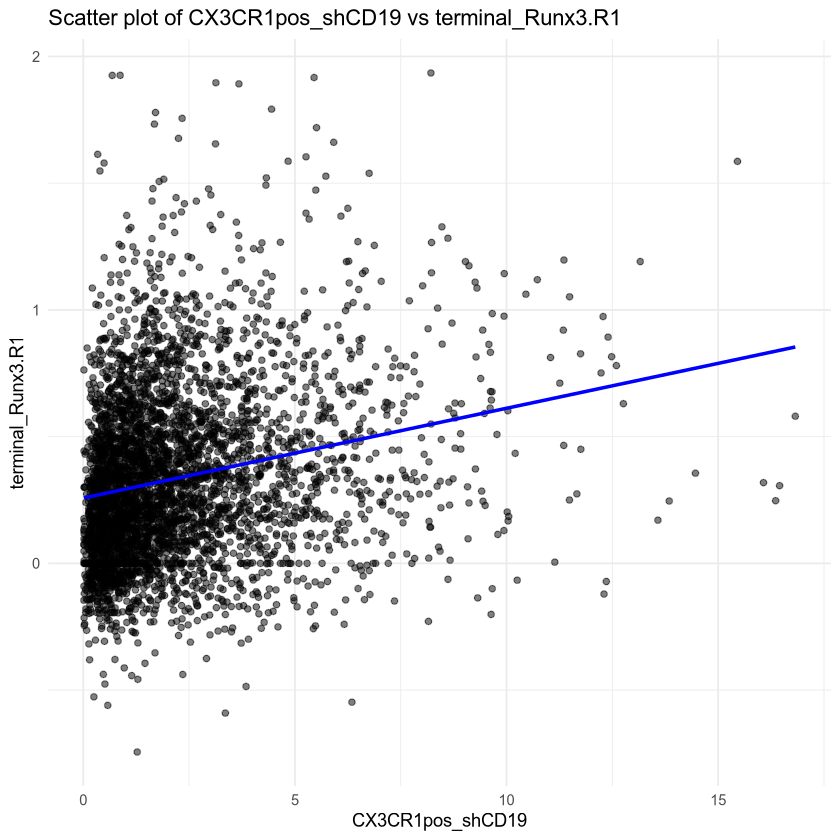

In [8]:
# column bind
combined <- data.frame(cbind(atac, cnr))
head(combined)

library(ggplot2)
# Scatter plot CX3CR1pos_shCD19 by terminal_Runx3.R1 
ggplot(combined, aes(x = CX3CR1pos_shCD19, y = terminal_Runx3.R1)) +
    geom_point(alpha = 0.5) + # add trendline
    geom_smooth(method = "lm", color = "blue", se = FALSE) +
    labs(title = "Scatter plot of CX3CR1pos_shCD19 vs terminal_Runx3.R1",
        x = "CX3CR1pos_shCD19",
        y = "terminal_Runx3.R1") +
    theme_minimal()

In [ ]:
# Scatter plot GFPneg_shCD19 by late_Runx3.R1
ggplot(combined, aes(x = GFPneg_shCD19, y = late_Runx3.R1)) +
    geom_point(alpha = 0.5) + # add trendline
    geom_smooth(method = "lm", color = "blue", se = FALSE) +
    labs(title = "Scatter plot of GFPneg_shCD19 vs late_Runx3.R1",
        x = "GFPneg_shCD19",
        y = "late_Runx3.R1") +
    theme_minimal()

In [ ]:
# Scatter plot GFPneg_shCD19 by early_Runx3.R1
ggplot(combined, aes(x = GFPneg_shCD19, y = early_Runx3.R1)) +
    geom_point(alpha = 0.5) + # add trendline
    geom_smooth(method = "lm", color = "blue", se = FALSE) +
    labs(title = "Scatter plot of GFPneg_shCD19 vs early_Runx3.R1",
        x = "GFPneg_shCD19",
        y = "early_Runx3.R1") +
    theme_minimal()

In [ ]:
# Scatter plot GFPpos_shCD19 by memory_Runx3.R1
ggplot(combined, aes(x = GFPpos_shCD19, y = memory_Runx3.R1)) +
    geom_point(alpha = 0.5) + # add trendline
    geom_smooth(method = "lm", color = "blue", se = FALSE) +
    labs(title = "Scatter plot of GFPpos_shCD19 vs memory_Runx3.R1",
        x = "GFPpos_shCD19",
        y = "memory_Runx3.R1") +
    theme_minimal()

In [ ]:
# Scatter plot GFPpos_shCD19 by shCd19_Runx3.R1
ggplot(combined, aes(x = GFPpos_shCD19, y = shCd19_Runx3.R1)) +
    geom_point(alpha = 0.5) + # add trendline
    geom_smooth(method = "lm", color = "blue", se = FALSE) +
    labs(title = "Scatter plot of GFPpos_shCD19 vs shCd19_Runx3.R1",
        x = "GFPpos_shCD19",
        y = "shCd19_Runx3.R1") +
    theme_minimal()